# Image EDA — Binary Classification Dataset

This notebook performs a thorough exploratory data analysis of a binary image classification dataset.
It covers dataset overview, sample visualisation, dimension and colour analysis, data quality checks,
and train/test consistency.
## Setup & Imports

In [1]:
import sys
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image

# Add src/ to the path so we can import image_eda
sys.path.insert(0, os.path.join("..", "src"))
from image_eda import (
    load_image_manifest,
    compute_pixel_stats,
    compute_mean_image,
    detect_duplicates,
)

# ── Configuration ────────────────────────────────────────────────────────────
DATA_ROOT = os.path.join("..", "data")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid", palette="Set2")
print(f"Python  : {sys.version}")
print(f"Data root: {os.path.abspath(DATA_ROOT)}")

# Load manifest
manifest = load_image_manifest(DATA_ROOT)
print(f"Manifest rows: {len(manifest)}")
manifest.head()

# Compute pixel stats and merge onto manifest
pixel_stats = compute_pixel_stats(manifest, sample_n=500)
df = manifest.merge(pixel_stats, on="filepath", how="left")
print(f"Merged DataFrame shape: {df.shape}")
df.head()

Python  : 3.13.12 | packaged by conda-forge | (main, Feb  5 2026, 05:53:46) [GCC 14.3.0]
Data root: /home/jovyan/work/data
Manifest rows: 2506


Merged DataFrame shape: (2506, 16)


,filepath,split,label,is_corrupt,width,height,mode,file_size_bytes,mean_r,mean_g,mean_b,std_r,std_g,std_b,mean_brightness,std_brightness
0,../data/Train/Positives/0882100000010295.png,train,positive,False,45,78,RGB,4599,83.202560,83.383194,83.423363,78.233833,79.117599,79.149773,83.301422,78.682732
1,../data/Train/Positives/0882100000008438.png,train,positive,False,50,59,RGB,3688,53.306442,56.097965,57.515934,55.058220,57.774120,59.082115,55.386780,57.051407
2,../data/Train/Positives/0928100000109838.png,train,positive,False,66,43,RGB,4295,77.775543,81.832977,82.152924,72.619659,76.246353,76.185097,80.612404,75.100922
3,../data/Train/Positives/0882100000023964.png,train,positive,False,50,54,RGB,3739,63.912594,68.014442,69.435555,64.736084,68.706703,70.042252,66.907776,67.613693
4,../data/Train/Positives/0882100000003864.png,train,positive,False,76,38,RGB,4181,79.955330,86.813713,87.292938,67.543755,73.004295,73.722862,84.791206,71.371788


---
## Section 1 — Dataset Overview

Total images  : 2506
Corrupt images: 0 (0.0%)

Per split × label counts:
split    label  count
 test negative    300
 test positive    188
train negative   1200
train positive    818

Class balance ratio (positive / negative) per split:
label  positive  negative  balance_ratio (pos/neg)
split                                             
test        188       300                 0.626667
train       818      1200                 0.681667


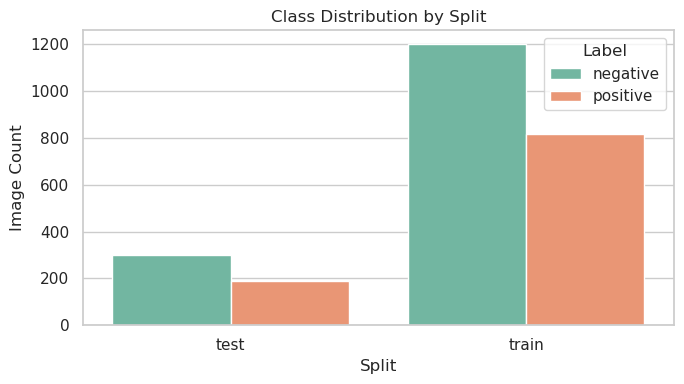

In [2]:
total = len(df)
n_corrupt = df["is_corrupt"].sum()
print(f"Total images  : {total}")
print(f"Corrupt images: {n_corrupt} ({n_corrupt / total * 100:.1f}%)")
print()

counts = df.groupby(["split", "label"]).size().rename("count").reset_index()
print("Per split × label counts:")
print(counts.to_string(index=False))
print()

# Class balance per split
pivot = counts.pivot(index="split", columns="label", values="count").fillna(0)
pivot["balance_ratio (pos/neg)"] = pivot.get("positive", 0) / pivot.get("negative", 1)
print("Class balance ratio (positive / negative) per split:")
print(pivot[["positive", "negative", "balance_ratio (pos/neg)"]].to_string())

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=counts,
    x="split",
    y="count",
    hue="label",
    ax=ax,
)
ax.set_title("Class Distribution by Split")
ax.set_xlabel("Split")
ax.set_ylabel("Image Count")
ax.legend(title="Label")
fig.tight_layout()

---
## Section 2 — Sample Images

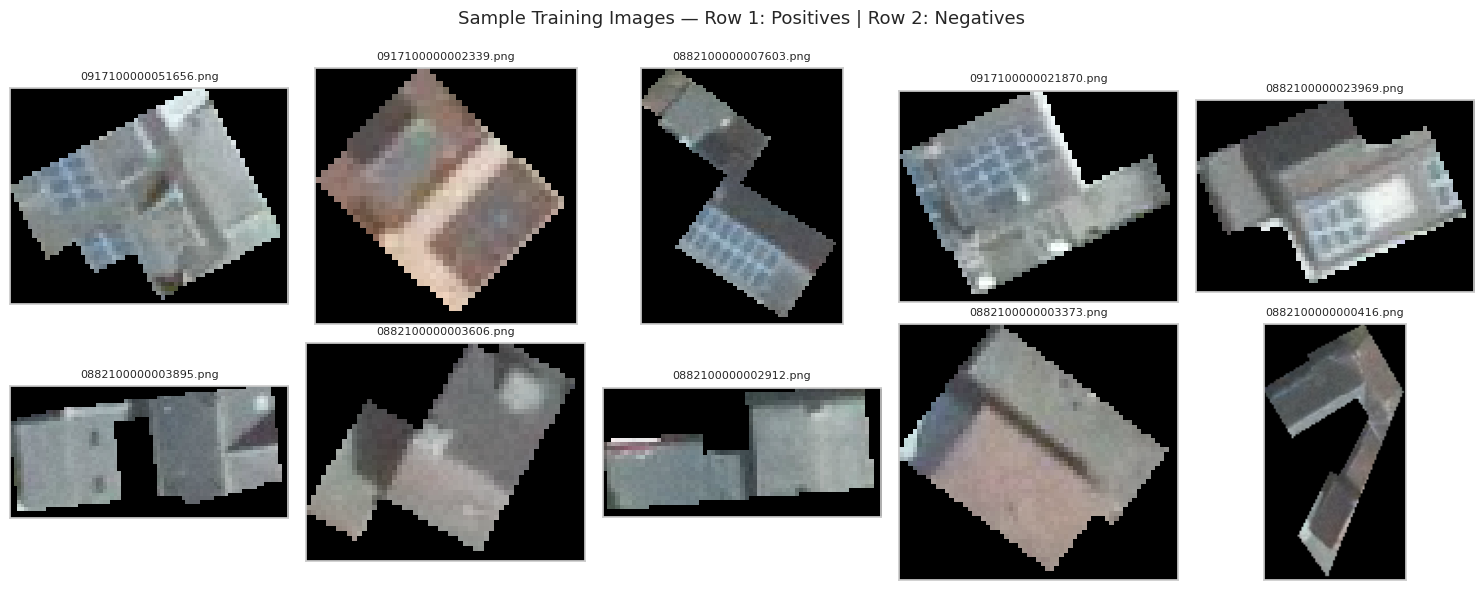

In [3]:
rng = np.random.default_rng(SEED)

train_valid = df[(df["split"] == "train") & (~df["is_corrupt"])]
pos_sample = train_valid[train_valid["label"] == "positive"]["filepath"].tolist()
neg_sample = train_valid[train_valid["label"] == "negative"]["filepath"].tolist()

pos_picks = rng.choice(pos_sample, size=min(5, len(pos_sample)), replace=False).tolist()
neg_picks = rng.choice(neg_sample, size=min(5, len(neg_sample)), replace=False).tolist()

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Sample Training Images — Row 1: Positives | Row 2: Negatives", fontsize=13)

for col, fpath in enumerate(pos_picks):
    ax = axes[0, col]
    try:
        img = Image.open(fpath).convert("RGB")
        ax.imshow(np.asarray(img))
    except Exception:
        ax.text(0.5, 0.5, "Error", ha="center", va="center")
    ax.set_title(os.path.basename(fpath)[:20], fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])

for col, fpath in enumerate(neg_picks):
    ax = axes[1, col]
    try:
        img = Image.open(fpath).convert("RGB")
        ax.imshow(np.asarray(img))
    except Exception:
        ax.text(0.5, 0.5, "Error", ha="center", va="center")
    ax.set_title(os.path.basename(fpath)[:20], fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])

# Hide any unused axes
for row in range(2):
    for col in range(5):
        if (row == 0 and col >= len(pos_picks)) or (row == 1 and col >= len(neg_picks)):
            axes[row, col].axis("off")

fig.tight_layout()

---
## Section 3 — Image Dimensions & Consistency

Unique width × height combinations:
 width  height  count
    29      42      7
    47      41      6
    33      48      6
    55      27      6
    50      41      6
    48      44      6
    47      46      5
    45      46      5
    41      44      5
    31      41      5
    33      52      5
    51      42      5
    48      54      5
    46      55      5
    43      45      5
    30      41      5
    43      44      5
    54      66      5
    49      41      5
    50      39      5
    43      36      5
    44      52      5
    52      60      5
    32      36      5
    32      52      5
    64      52      4
    56      57      4
    50      38      4
    56      39      4
    42      44      4
    36      50      4
    39      39      4
    46      56      4
    42      49      4
    39      43      4
    37      31      4
    54      43      4
    43      46      4
    30      42      4
    52      59      4
    30      35      4
    35      53      4
    30      33    

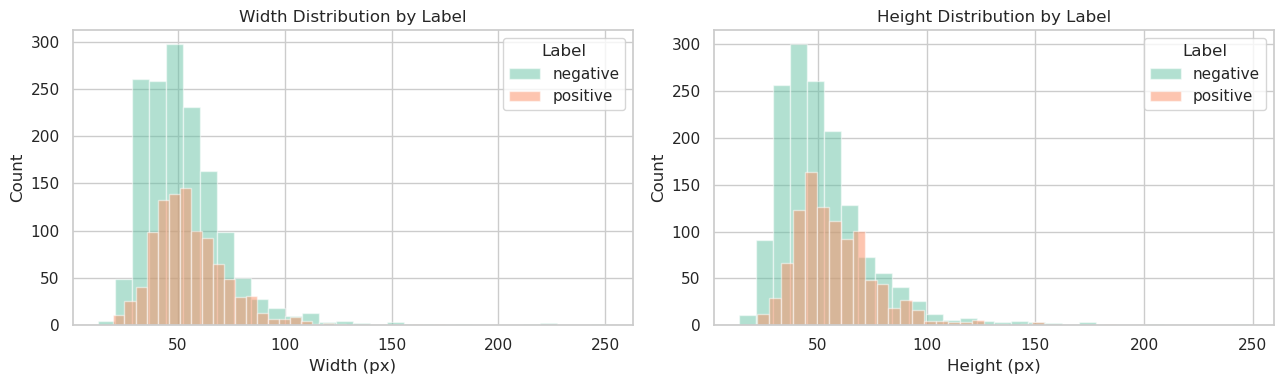

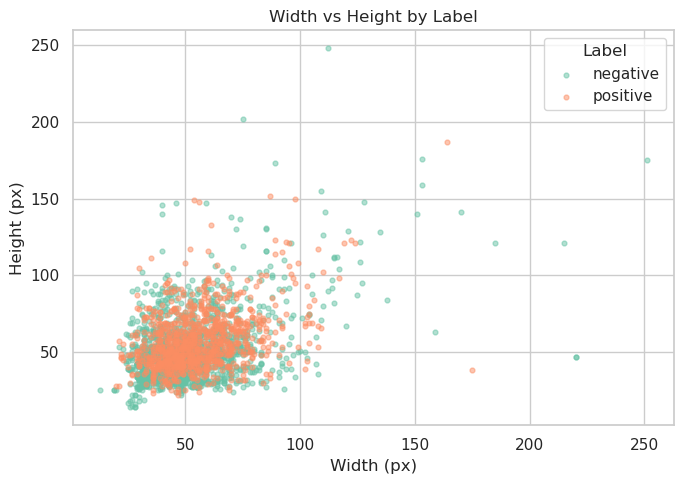

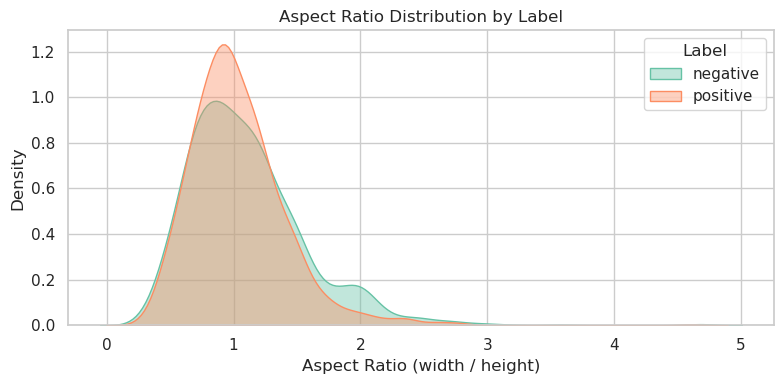

In [4]:
valid = df[~df["is_corrupt"]].copy()
valid["aspect_ratio"] = valid["width"] / valid["height"]

dim_counts = valid.groupby(["width", "height"]).size().reset_index(name="count").sort_values("count", ascending=False)
print("Unique width × height combinations:")
print(dim_counts.to_string(index=False))
print()

all_same_size = len(dim_counts) == 1
if all_same_size:
    w, h = int(dim_counts.iloc[0]["width"]), int(dim_counts.iloc[0]["height"])
    print(f"all_same_size = True  — Every image is {w} × {h} pixels. No resizing required before model training.")
else:
    print(f"all_same_size = False — Images have {len(dim_counts)} different size(s). Resizing will be needed before training.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label_val, grp in valid.groupby("label"):
    axes[0].hist(grp["width"], bins=30, alpha=0.5, label=label_val)
axes[0].set_title("Width Distribution by Label")
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Count")
axes[0].legend(title="Label")

for label_val, grp in valid.groupby("label"):
    axes[1].hist(grp["height"], bins=30, alpha=0.5, label=label_val)
axes[1].set_title("Height Distribution by Label")
axes[1].set_xlabel("Height (px)")
axes[1].set_ylabel("Count")
axes[1].legend(title="Label")

fig.tight_layout()

fig, ax = plt.subplots(figsize=(7, 5))
for label_val, grp in valid.groupby("label"):
    ax.scatter(grp["width"], grp["height"], alpha=0.5, label=label_val, s=12)
ax.set_title("Width vs Height by Label")
ax.set_xlabel("Width (px)")
ax.set_ylabel("Height (px)")
ax.legend(title="Label")
fig.tight_layout()

fig, ax = plt.subplots(figsize=(8, 4))
for label_val, grp in valid.groupby("label"):
    sns.kdeplot(grp["aspect_ratio"], ax=ax, label=label_val, fill=True, alpha=0.4)
ax.set_title("Aspect Ratio Distribution by Label")
ax.set_xlabel("Aspect Ratio (width / height)")
ax.set_ylabel("Density")
ax.legend(title="Label")
fig.tight_layout()

---
## Section 4 — Color Space Analysis

Image mode value counts per split × label:
split    label mode  count
 test negative  RGB    300
 test positive  RGB    188
train negative  RGB   1200
train positive  RGB    817
train positive RGBA      1

Non-RGB images detected (1 files):
                                    filepath split    label mode
../data/Train/Positives/0917100000000790.png train positive RGBA


Computing mean image: 100%|██████████| 1200/1200 [00:00<00:00, 1337.91it/s]


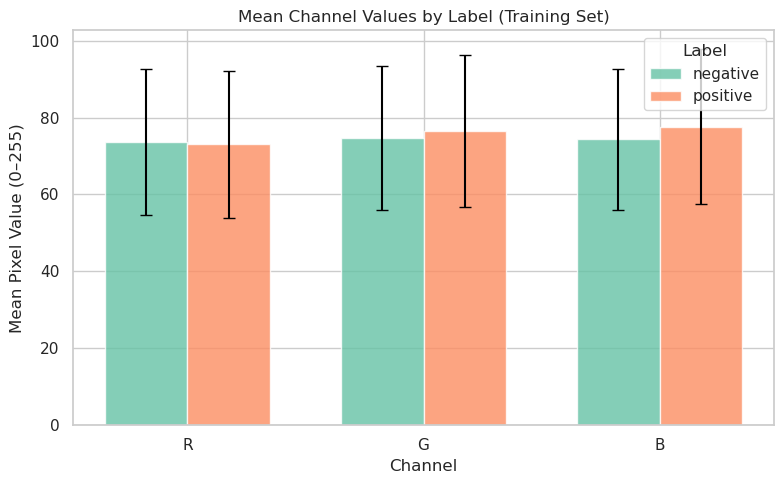

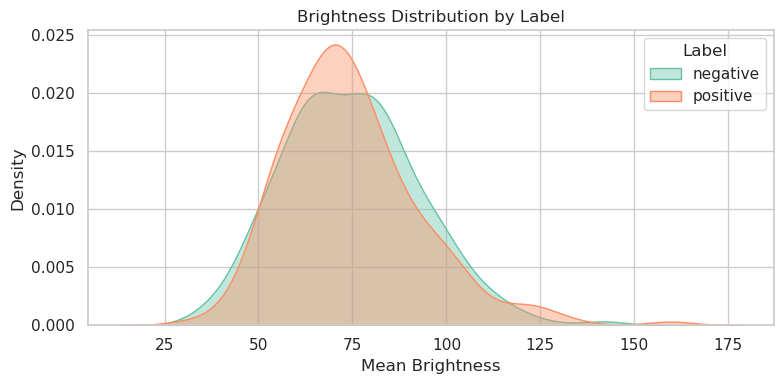

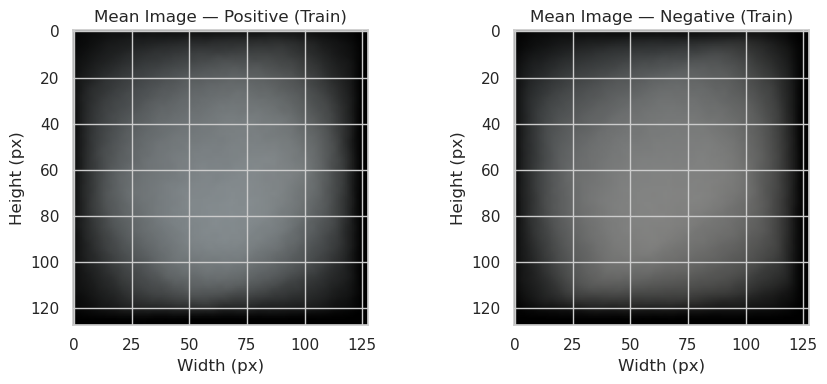

In [5]:
mode_counts = df[~df["is_corrupt"]].groupby(["split", "label", "mode"]).size().reset_index(name="count")
print("Image mode value counts per split × label:")
print(mode_counts.to_string(index=False))
print()

non_rgb = df[(~df["is_corrupt"]) & (df["mode"] != "RGB")]
if non_rgb.empty:
    print("All valid images are RGB — no colour-space issues found.")
else:
    print(f"Non-RGB images detected ({len(non_rgb)} files):")
    print(non_rgb[["filepath", "split", "label", "mode"]].to_string(index=False))

# Mean channel values per label (training set only)
train_df = df[(df["split"] == "train") & (~df["is_corrupt"])].dropna(subset=["mean_r", "mean_g", "mean_b"])

channel_summary = train_df.groupby("label").agg(
    mean_r=("mean_r", "mean"), std_r=("mean_r", "std"),
    mean_g=("mean_g", "mean"), std_g=("mean_g", "std"),
    mean_b=("mean_b", "mean"), std_b=("mean_b", "std"),
).reset_index()

channels = ["R", "G", "B"]
x = np.arange(len(channels))
labels_list = channel_summary["label"].tolist()
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
for i, row in channel_summary.iterrows():
    means = [row["mean_r"], row["mean_g"], row["mean_b"]]
    stds  = [row["std_r"],  row["std_g"],  row["std_b"]]
    offset = (i - len(channel_summary) / 2 + 0.5) * width
    ax.bar(x + offset, means, width, yerr=stds, label=row["label"], capsize=4, alpha=0.8)

ax.set_title("Mean Channel Values by Label (Training Set)")
ax.set_xlabel("Channel")
ax.set_ylabel("Mean Pixel Value (0–255)")
ax.set_xticks(x)
ax.set_xticklabels(channels)
ax.legend(title="Label")
fig.tight_layout()

# Brightness KDE — sample of 200 per label from training set
bright_df = train_df.dropna(subset=["mean_brightness"])
rng42 = np.random.default_rng(42)

fig, ax = plt.subplots(figsize=(8, 4))
for label_val, grp in bright_df.groupby("label"):
    sample = grp.sample(n=min(200, len(grp)), random_state=42)["mean_brightness"]
    sns.kdeplot(sample, ax=ax, label=label_val, fill=True, alpha=0.4)
ax.set_title("Brightness Distribution by Label")
ax.set_xlabel("Mean Brightness")
ax.set_ylabel("Density")
ax.legend(title="Label")
fig.tight_layout()

# Mean images — Positives vs Negatives (training set)
train_pos_paths = df[(df["split"] == "train") & (df["label"] == "positive") & (~df["is_corrupt"])]["filepath"].tolist()
train_neg_paths = df[(df["split"] == "train") & (df["label"] == "negative") & (~df["is_corrupt"])]["filepath"].tolist()

mean_pos = compute_mean_image(train_pos_paths, target_size=(128, 128))
mean_neg = compute_mean_image(train_neg_paths, target_size=(128, 128))

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(mean_pos)
axes[0].set_title("Mean Image — Positive (Train)")
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Height (px)")

axes[1].imshow(mean_neg)
axes[1].set_title("Mean Image — Negative (Train)")
axes[1].set_xlabel("Width (px)")
axes[1].set_ylabel("Height (px)")

fig.tight_layout()

---
## Section 5 — Brightness & Contrast

Very dark  images (mean_brightness < 20) : 0
Very bright images (mean_brightness > 235): 0
  No examples for: Very Dark Images  (mean brightness < 20)
  No examples for: Very Bright Images (mean brightness > 235)


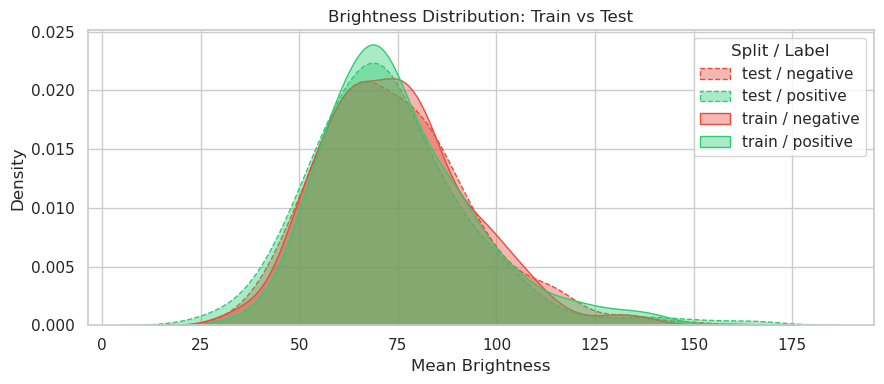

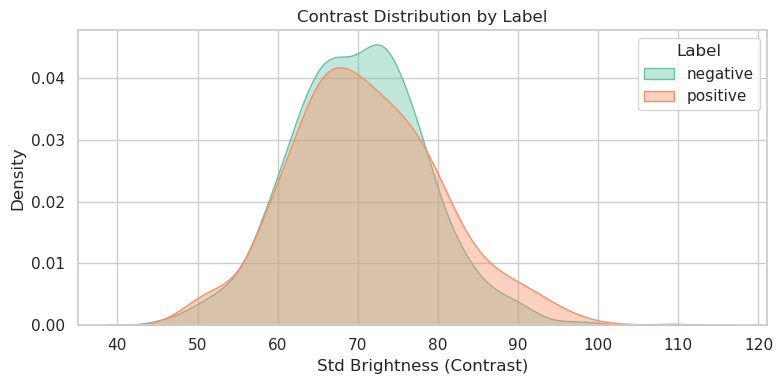

In [6]:
# KDE of mean_brightness per label per split
bright_valid = df[~df["is_corrupt"]].dropna(subset=["mean_brightness"])

fig, ax = plt.subplots(figsize=(9, 4))
palette = {"positive": "#2ecc71", "negative": "#e74c3c"}
linestyles = {"train": "-", "test": "--"}

for (split, label), grp in bright_valid.groupby(["split", "label"]):
    sns.kdeplot(
        grp["mean_brightness"],
        ax=ax,
        label=f"{split} / {label}",
        color=palette[label],
        linestyle=linestyles[split],
        fill=True,
        alpha=0.4,
    )
ax.set_title("Brightness Distribution: Train vs Test")
ax.set_xlabel("Mean Brightness")
ax.set_ylabel("Density")
ax.legend(title="Split / Label")
fig.tight_layout()

# KDE of std_brightness (contrast) per label
contrast_valid = df[~df["is_corrupt"]].dropna(subset=["std_brightness"])

fig, ax = plt.subplots(figsize=(8, 4))
for label_val, grp in contrast_valid.groupby("label"):
    sns.kdeplot(grp["std_brightness"], ax=ax, label=label_val, fill=True, alpha=0.4)
ax.set_title("Contrast Distribution by Label")
ax.set_xlabel("Std Brightness (Contrast)")
ax.set_ylabel("Density")
ax.legend(title="Label")
fig.tight_layout()

# Very dark / very bright images
bright_valid = df[~df["is_corrupt"]].dropna(subset=["mean_brightness"])
very_dark   = bright_valid[bright_valid["mean_brightness"] < 20]
very_bright = bright_valid[bright_valid["mean_brightness"] > 235]

print(f"Very dark  images (mean_brightness < 20) : {len(very_dark)}")
print(f"Very bright images (mean_brightness > 235): {len(very_bright)}")

def show_extreme_examples(filepaths, title, n=3):
    """Display up to n example images for extreme brightness cases."""
    picks = filepaths[:n]
    if not picks:
        print(f"  No examples for: {title}")
        return
    fig, axes = plt.subplots(1, len(picks), figsize=(4 * len(picks), 4))
    if len(picks) == 1:
        axes = [axes]
    fig.suptitle(title)
    for ax, fpath in zip(axes, picks):
        try:
            img = Image.open(fpath).convert("RGB")
            ax.imshow(np.asarray(img))
        except Exception:
            ax.text(0.5, 0.5, "Error", ha="center", va="center")
        ax.set_title(os.path.basename(fpath)[:20], fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])
    fig.tight_layout()

show_extreme_examples(very_dark["filepath"].tolist(),   "Very Dark Images  (mean brightness < 20)",  n=3)
show_extreme_examples(very_bright["filepath"].tolist(), "Very Bright Images (mean brightness > 235)", n=3)

---
## Section 6 — Data Quality Issues

In [7]:
# Corrupt files
corrupt = df[df["is_corrupt"]]
if corrupt.empty:
    print("No corrupt files found.")
else:
    print(f"Corrupt files ({len(corrupt)}):")
    for _, row in corrupt.iterrows():
        print(f"  [{row['split']}/{row['label']}]  {row['filepath']}")

# Duplicate detection
df_with_hashes = detect_duplicates(df)
dup_df = df_with_hashes[df_with_hashes["is_duplicate"]]
n_dup_hashes = df_with_hashes.loc[df_with_hashes["is_duplicate"], "file_hash"].nunique()

print(f"Duplicate hash groups  : {n_dup_hashes}")
print(f"Images involved in dups: {len(dup_df)}")

if not dup_df.empty:
    print()
    print("Split / label breakdown of duplicates:")
    print(dup_df.groupby(["split", "label"]).size().reset_index(name="count").to_string(index=False))
    print()
    print("Duplicate file paths:")
    for _, row in dup_df.iterrows():
        print(f"  hash={row['file_hash'][:10]}…  [{row['split']}/{row['label']}]  {row['filepath']}")

# Quality summary table
very_dark_n   = len(df[~df["is_corrupt"]].dropna(subset=["mean_brightness"])
                     .query("mean_brightness < 20"))
very_bright_n = len(df[~df["is_corrupt"]].dropna(subset=["mean_brightness"])
                     .query("mean_brightness > 235"))

quality_summary = pd.DataFrame({
    "Issue": [
        "Total images",
        "Corrupt / unreadable",
        "Duplicate files",
        "Very dark (brightness < 20)",
        "Very bright (brightness > 235)",
    ],
    "Count": [
        len(df),
        int(df["is_corrupt"].sum()),
        len(dup_df),
        very_dark_n,
        very_bright_n,
    ],
})
quality_summary["% of Total"] = (quality_summary["Count"] / len(df) * 100).round(2)
print("\n=== Data Quality Summary ===")
print(quality_summary.to_string(index=False))

No corrupt files found.


Hashing files: 100%|██████████| 2506/2506 [00:00<00:00, 8354.31it/s]


Duplicate hash groups  : 0
Images involved in dups: 0

=== Data Quality Summary ===
                         Issue  Count  % of Total
                  Total images   2506       100.0
          Corrupt / unreadable      0         0.0
               Duplicate files      0         0.0
   Very dark (brightness < 20)      0         0.0
Very bright (brightness > 235)      0         0.0


---
## Section 7 — Train / Test Consistency Check

=== Train / Test Metric Summary ===
         Metric Split    Label   Mean    Std   N
mean_brightness  test negative 74.623 19.376 300
mean_brightness  test positive 72.748 20.447 188
mean_brightness train negative 74.330 18.584 500
mean_brightness train positive 75.537 19.598 500
 std_brightness  test negative 70.201  8.827 300
 std_brightness  test positive 70.064  9.272 188
 std_brightness train negative 69.881  8.065 500
 std_brightness train positive 71.365  9.669 500
         mean_r  test negative 74.263 19.554 300
         mean_r  test positive 70.315 19.931 188
         mean_r train negative 73.606 18.992 500
         mean_r train positive 73.043 19.061 500
         mean_g  test negative 74.942 19.578 300
         mean_g  test positive 73.669 20.711 188
         mean_g train negative 74.763 18.700 500
         mean_g train positive 76.479 19.859 500
         mean_b  test negative 74.256 19.351 300
         mean_b  test positive 74.732 20.905 188
         mean_b train negative 74

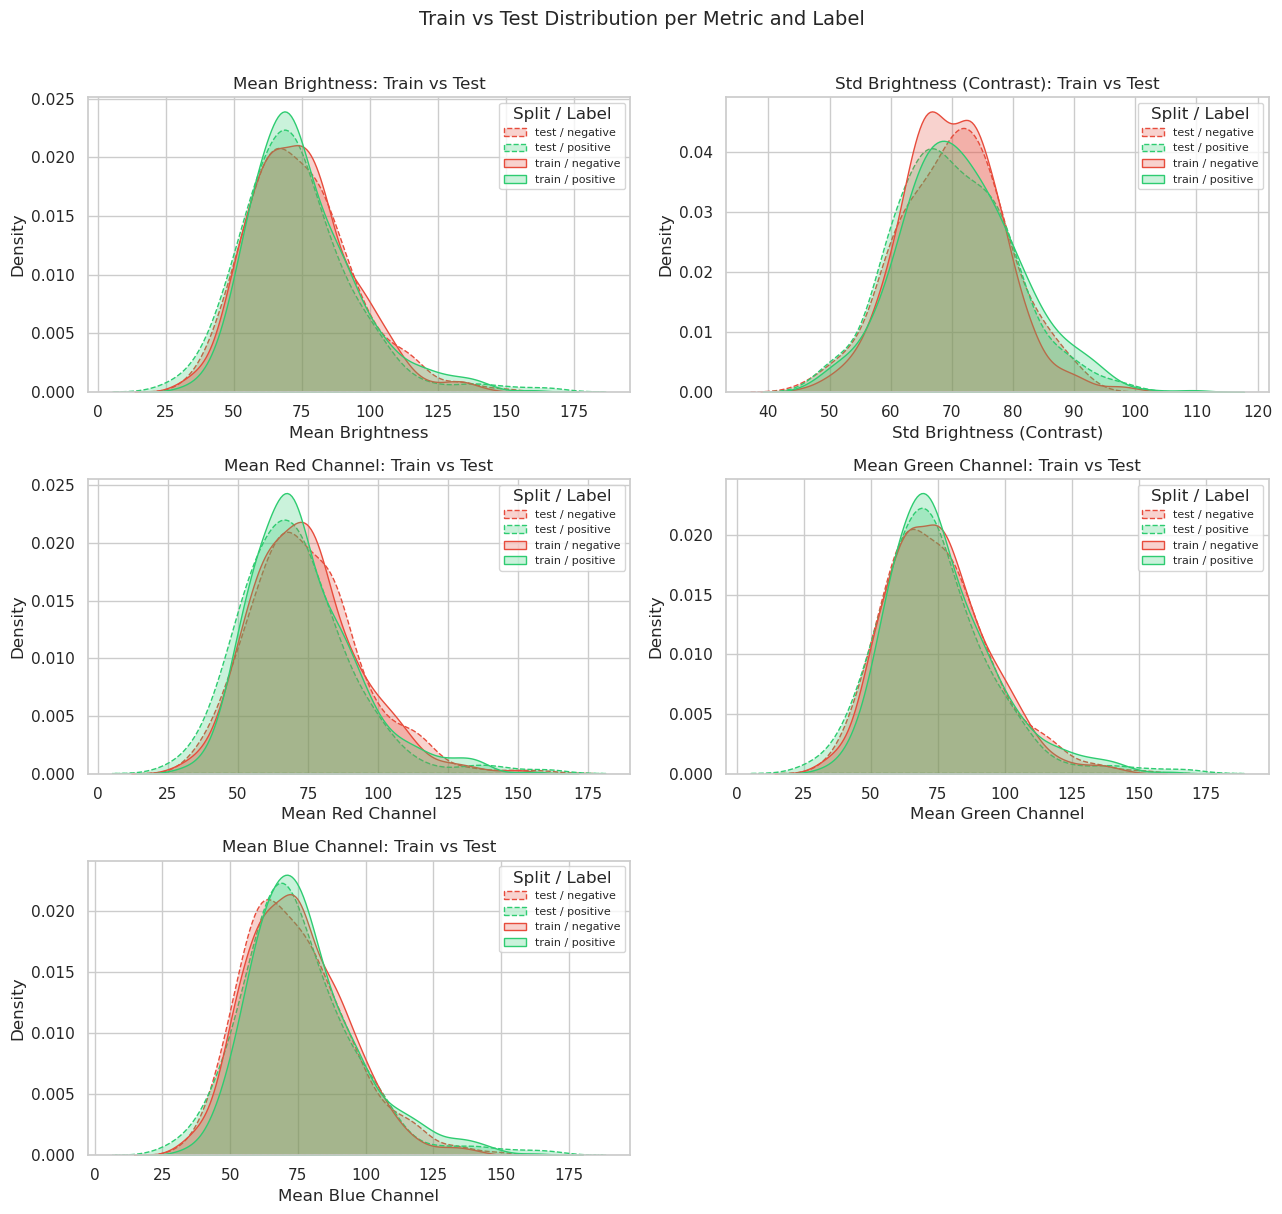

In [8]:
metrics = ["mean_brightness", "std_brightness", "mean_r", "mean_g", "mean_b"]
metric_labels = {
    "mean_brightness": "Mean Brightness",
    "std_brightness":  "Std Brightness (Contrast)",
    "mean_r": "Mean Red Channel",
    "mean_g": "Mean Green Channel",
    "mean_b": "Mean Blue Channel",
}
label_colors = {"positive": "#2ecc71", "negative": "#e74c3c"}
split_ls     = {"train": "-", "test": "--"}

consistency_df = df[~df["is_corrupt"]].dropna(subset=metrics)

n_cols = 2
n_rows = (len(metrics) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 4 * n_rows))
axes_flat = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes_flat[i]
    for (split, label), grp in consistency_df.groupby(["split", "label"]):
        sns.kdeplot(
            grp[metric],
            ax=ax,
            color=label_colors[label],
            linestyle=split_ls[split],
            label=f"{split} / {label}",
            fill=True,
            alpha=0.25,
        )
    ax.set_title(f"{metric_labels[metric]}: Train vs Test")
    ax.set_xlabel(metric_labels[metric])
    ax.set_ylabel("Density")
    ax.legend(title="Split / Label", fontsize=8)

# Hide any leftover axes
for j in range(len(metrics), len(axes_flat)):
    axes_flat[j].axis("off")

fig.suptitle("Train vs Test Distribution per Metric and Label", fontsize=14, y=1.01)
fig.tight_layout()

# Mean and std per split per label for each metric
summary_rows = []
for metric in metrics:
    for (split, label), grp in consistency_df.groupby(["split", "label"]):
        vals = grp[metric].dropna()
        summary_rows.append({
            "Metric": metric,
            "Split": split,
            "Label": label,
            "Mean": round(vals.mean(), 3),
            "Std": round(vals.std(), 3),
            "N": len(vals),
        })

summary_table = pd.DataFrame(summary_rows)
print("=== Train / Test Metric Summary ===")
print(summary_table.to_string(index=False))

### Interpretation — Train / Test Distributional Consistency

**What the figures show:** The KDE curves for train (solid) and test (dashed) overlap almost perfectly for every metric and both class labels. The quantitative summary confirms this:

| Metric | Δ mean (negative) | Δ mean (positive) | Within 1 σ? |
|---|---|---|---|
| Mean brightness | 0.3 px | 2.8 px | Yes (σ ≈ 19–20) |
| Std brightness (contrast) | 0.3 px | 1.3 px | Yes (σ ≈ 8–9) |
| Mean R | 0.7 px | 2.7 px | Yes (σ ≈ 19–20) |
| Mean G | 0.2 px | 2.8 px | Yes (σ ≈ 19–21) |
| Mean B | 0.1 px | 2.9 px | Yes (σ ≈ 18–21) |

All train/test differences are well below one standard deviation. There is **no meaningful distributional gap** — the train/test split preserves the same brightness and colour statistics in both halves of the data. No domain shift mitigation is required.

**The more important finding:** Positive and negative samples are nearly **indistinguishable on these low-level pixel statistics**. Across all five metrics, the two classes have almost identical means and spreads (e.g., mean brightness: positives ≈ 73–76, negatives ≈ 74–75; all RGB channels similarly overlapping). The only marginal signal is that training positives have a slightly elevated mean blue channel (≈ 77.6 vs. 74.3 for negatives), which is absent in the test set — suggesting it reflects sampling variation rather than a genuine class characteristic.